# **Processamento com NLTK e spaCy**

#**Tokenização e Análise de Estrutura de Texto**

In [20]:
# ===============================
# Imports padrão
# ===============================
import time
from collections import Counter

# ===============================
# Manipulação de dados
# ===============================
import pandas as pd

# ===============================
# Visualização
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# NLP - NLTK
# ===============================
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, mac_morpho
from nltk.stem import RSLPStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.tag import UnigramTagger

# ===============================
# NLP - spaCy
# ===============================
import spacy
from spacy import displacy

# ===============================
# Instalações
# ===============================
!pip install langdetect
!pip install spacy kagglehub
!pip install langdetect

# ===============================
# Outros
# ===============================
import kagglehub
from kagglehub import KaggleDatasetAdapter
from langdetect import detect

# ===============================
# Download do modelo spaCy (português)
# ===============================
!python -m spacy download pt_core_news_sm

# ===============================
# Downloads necessários do NLTK
# ===============================
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('rslp')
nltk.download('mac_morpho')
nltk.download('averaged_perceptron_tagger_eng')

  Using cached https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.8.0/pt_core_news_sm-3.8.0-py3-none-any.whl (13.0 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading package mac_morpho to /root/nltk_data...
[nltk_data]   Package mac_morpho is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [3]:
file_path = "portuguese-poems.csv"

# Baixando e carregando dataset
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "oliveirasp6/poems-in-portuguese",
  file_path, pandas_kwargs={'encoding':'utf-8'}
)

print(df)

Using Colab cache for faster access to the 'poems-in-portuguese' dataset.
                           Author                                      Title  \
0                Cecília Meireles                                    Retrato   
1                 Fernando Pessoa          Para ser grande, sê inteiro: nada   
2                Marina Colasanti                      Eu sei, mas não devia   
3      Carlos Drummond de Andrade                                  Quadrilha   
4              Eugénio de Andrade                           É urgente o amor   
...                           ...                                        ...   
15538             Hashem Shaabani  Sete razões pelas quais eu deveria morrer   
15539        Helmut Heissenbüttel             Manchas de tinta fogem céleres   
15540        Leónidas Lamborghini                            Falando sozinho   
15541             Fernando Namora             Por Todos os Caminhos do Mundo   
15542         Guillermo Fernández          Dis

**Tokenização por NLTK**

In [4]:
# Selecionar um poema de exemplo
poema_exemplo = df.iloc[0]['Content']
print("POEMA ORIGINAL:")
print(poema_exemplo[:200] + "...\n")


# Tokenizando o texto por palavras
# Utilizando NLTK
tk_palavras = word_tokenize(poema_exemplo, language='portuguese')
print(f"Total de tokens (palavras): {len(tk_palavras)}")
print(f"Primeiros 10 tokens: {tk_palavras[:10]}\n")

# Tokenizando o texto por frases
# Utilizando NLTK
tk_frases = sent_tokenize(poema_exemplo, language='portuguese')
print(f"Total de sentenças: {len(tk_frases)}")
print(f"Primeira sentença: {tk_frases[0]}\n")


POEMA ORIGINAL:
Eu não tinha este rosto de hoje,
Assim calmo, assim triste, assim magro,
Nem estes olhos tão vazios,
Nem o lábio amargo.

Eu não tinha estas mãos sem força,
Tão paradas e frias e mortas;
Eu não ...

Total de tokens (palavras): 79
Primeiros 10 tokens: ['Eu', 'não', 'tinha', 'este', 'rosto', 'de', 'hoje', ',', 'Assim', 'calmo']

Total de sentenças: 3
Primeira sentença: Eu não tinha este rosto de hoje,
Assim calmo, assim triste, assim magro,
Nem estes olhos tão vazios,
Nem o lábio amargo.



**Tokenização utilizando spaCy**

In [5]:


nlp = spacy.load('pt_core_news_sm') # Setando as configs do spaCy
doc = nlp(poema_exemplo)

# Listando a quantidade de tokens criados e a quantidade de sentenças obtidas
print(f"Tokens spaCy: {len([token for token in doc])}")
print(f"Sentenças spaCy: {len(list(doc.sents))}\n")

# Printando os 10 primeiros tokens utilizando spaCy
# Mostra a palavra e sua Classe Gramatical
print("\nESTRUTURA DE TOKENS (spaCy):")
for i, token in enumerate(doc[:10]):
    print(f"  {i+1}. '{token.text}' - tipo: {token.pos_}")


Tokens spaCy: 90
Sentenças spaCy: 4


ESTRUTURA DE TOKENS (spaCy):
  1. 'Eu' - tipo: PRON
  2. 'não' - tipo: ADV
  3. 'tinha' - tipo: VERB
  4. 'este' - tipo: DET
  5. 'rosto' - tipo: NOUN
  6. 'de' - tipo: ADP
  7. 'hoje' - tipo: ADV
  8. ',' - tipo: PUNCT
  9. '
' - tipo: SPACE
  10. 'Assim' - tipo: ADV


# **Comparação**

In [6]:
# Comparando a quantidade de Tokens gerados por cada metodo de Tokenização

print("COMPARAÇÃO NLTK vs spaCy:")
print(f"  NLTK tokens: {len(tk_palavras)}")
print(f"  spaCy tokens: {len([token for token in doc])}")
print(f"  Diferença: {abs(len(tk_palavras) - len([token for token in doc]))}")

COMPARAÇÃO NLTK vs spaCy:
  NLTK tokens: 79
  spaCy tokens: 90
  Diferença: 11


#**Limpeza e Normalização com Stopwords, Stemming e Lematização**

**Remoção de STOPWORDS**

In [7]:
# Vai carregar as StopWords pré-setadas pelo NLTK em português
stop_words = set(stopwords.words('portuguese'))

#Limpeza do df original para uso futuro
df['Content'] = df['Content'].str.replace(r'[\r\n\t]+', ' ', regex=True).str.strip()

# filtrando os tokens e removendo StopWords e tudo que não seja letra, como números e Sinais.
# Também deixa tudo em Minúsculo
tk_limpos = [token.lower() for token in tk_palavras
             if token.lower not in stop_words and token.isalpha()]

# Vai mostrar os tokens antes e depois da remoção e a porcentagem de redução
print(f"Tokens originais: {len(tk_palavras)}")
print(f"Tokens sem stopwords: {len(tk_limpos)}")
print(f"Redução: {((len(tk_palavras) - len(tk_limpos)) / len(tk_palavras) * 100):.1f}%\n")

print(f"Primeiros 20 tokens limpos: {tk_limpos[:20]}\n")


Tokens originais: 79
Tokens sem stopwords: 64
Redução: 19.0%

Primeiros 20 tokens limpos: ['eu', 'não', 'tinha', 'este', 'rosto', 'de', 'hoje', 'assim', 'calmo', 'assim', 'triste', 'assim', 'magro', 'nem', 'estes', 'olhos', 'tão', 'vazios', 'nem', 'o']



**STEMMING**

In [8]:
# Setando a função de Stemming
stemmer = RSLPStemmer()

# Aplicando o Stemming nos tokens já tratados anteriormente
tk_stm = [stemmer.stem(tk) for tk in tk_limpos]

In [9]:
# Aqui temos um exemplo de como o metodo de STEMMING funciona na prática
print("STEMMING - Exemplos de redução:")
exemplos = [
    'computador', 'computadores', 'computação',
    'correr', 'correndo', 'corrida',
    'belo', 'beleza', 'belíssimo'
]

# Mostrando o antes e depos do processo
for palavra in exemplos:
    stem = stemmer.stem(palavra)
    print(f"  {palavra:15} → {stem}")

STEMMING - Exemplos de redução:
  computador      → comput
  computadores    → comput
  computação      → comput
  correr          → corr
  correndo        → corr
  corrida         → corr
  belo            → bel
  beleza          → bel
  belíssimo       → bel


**LEMATIZAÇÃO**

In [10]:
# Vai fazer o processo de lematização nos tokens adquiridos pelo spaCy
# Também vai remover StopWords e tudo que não seja letra, como números e Sinais.
tk_lmt = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

# Aqui temos um exemplo de como o metodo de LEMATIZAÇÃO funciona na prática
print("\nLEMATIZAÇÃO spaCy - Exemplos:")
exemplos_doc = nlp("computador computadores computação correr correram correndo corrida belo beleza")
for token in exemplos_doc:
    if token.is_alpha:
        print(f"  {token.text:15} → {token.lemma_}")


LEMATIZAÇÃO spaCy - Exemplos:
  computador      → computador
  computadores    → computador
  computação      → computação
  correr          → correr
  correram        → correr
  correndo        → correr
  corrida         → corrida
  belo            → Belo
  beleza          → beleza


**COMPARAÇÃO**

In [11]:
# Aqui temos uma comparação simples do Steamming VS Lematização
print("\nCOMPARAÇÃO STEMMING vs LEMATIZAÇÃO: \n")
palavras_teste = ['correndo', 'correria', 'correr', 'corrida']
for palavra in palavras_teste:
    stem = stemmer.stem(palavra)
    token_doc = nlp(palavra)[0]
    lemma = token_doc.lemma_
    print(f"  {palavra:12} | Stem: {stem:10} | Lemma: {lemma}")


COMPARAÇÃO STEMMING vs LEMATIZAÇÃO: 

  correndo     | Stem: corr       | Lemma: correr
  correria     | Stem: corr       | Lemma: correrio
  correr       | Stem: corr       | Lemma: correr
  corrida      | Stem: corr       | Lemma: corrida


In [12]:

# Vai contar os itens iguais no Stemming e mostrar os vinte mais comuns.
freq_stm = Counter(tk_stm)
print("\n\nTop 20 STEMS mais frequentes:")
for stem, freq in freq_stm.most_common(20):
    print(f"  {stem:15} : {freq:3d}")

# Vai Contar A quantidade de intens sem repetir
print(f"\nTamanho total: {len(freq_stm)} Itens")

print("\n\n"+"="*30)



# Vai contar os itens iguais no Lemmatização e mostrar os vinte mais comuns.
freq_lmt = Counter(tk_lmt)
print("\n\nTop 20 LEMAS mais frequentes:")
for lm, freq in freq_lmt.most_common(20):
    print(f"  {lm:15} : {freq:3d}")

# Vai Contar A quantidade de intens sem repetir
print(f"\nTamanho total: {len(freq_lmt)} Itens")





Top 20 STEMS mais frequentes:
  est             :   5
  tão             :   5
  eu              :   4
  não             :   4
  tinh            :   3
  assim           :   3
  nem             :   3
  e               :   2
  que             :   2
  rost            :   1
  de              :   1
  hoj             :   1
  calm            :   1
  trist           :   1
  magr            :   1
  olh             :   1
  vazi            :   1
  o               :   1
  lábi            :   1
  amarg           :   1

Tamanho total: 42 Itens




Top 20 LEMAS mais frequentes:
  ter             :   3
  rosto           :   1
  hoje            :   1
  calmo           :   1
  triste          :   1
  magro           :   1
  olho            :   1
  vazio           :   1
  lábio           :   1
  amargo          :   1
  mão             :   1
  força           :   1
  parar           :   1
  frio            :   1
  morto           :   1
  coração         :   1
  mostrar         :   1
  dar             :  

# **Gráfico de impacto de normalização**

/tmp/ipykernel_12970/4248660353.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rotulos, y=valores, palette='viridis')


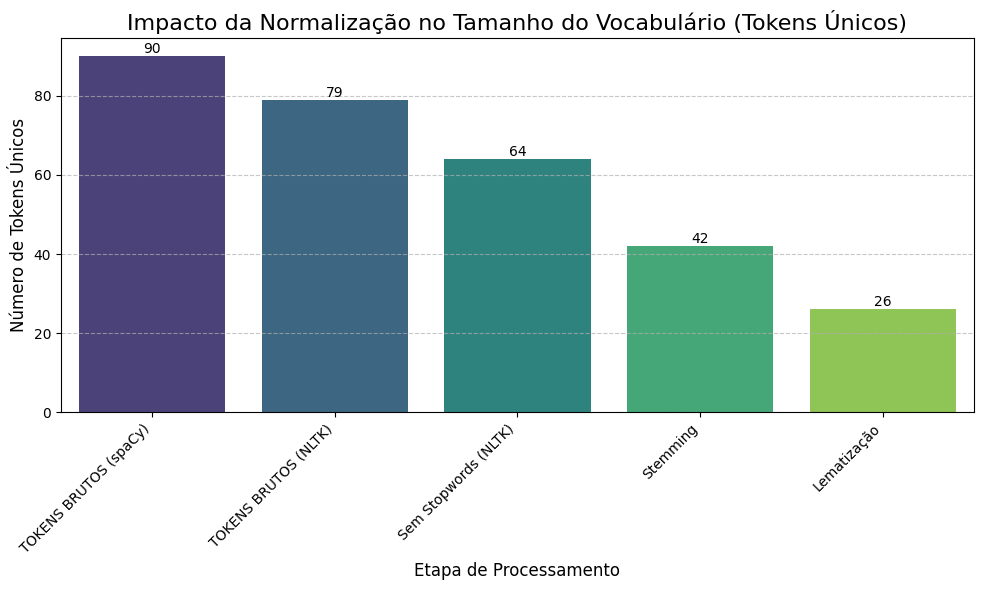

In [13]:

# Setando os itens do gráfico
tk_spacy_org = len(doc)
tk_nltk_org = len(tk_palavras)
tk_nltk_sem_stopwords = len(tk_limpos)
tk_stemmed = len(freq_stm)
tk_lematizado = len(freq_lmt)

# Definindo as colunas e suas respectivas descrições
rotulos = ['TOKENS BRUTOS (spaCy)','TOKENS BRUTOS (NLTK)', 'Sem Stopwords (NLTK)', 'Stemming', 'Lematização']
valores = [tk_spacy_org,tk_nltk_org, tk_nltk_sem_stopwords, tk_stemmed, tk_lematizado]

# Criando o Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=rotulos, y=valores, palette='viridis')

# Configurando descrições e aparencia do gráfico
plt.title('Impacto da Normalização no Tamanho do Vocabulário (Tokens Únicos)', fontsize=16)
plt.xlabel('Etapa de Processamento', fontsize=12)
plt.ylabel('Número de Tokens Únicos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Adicionar os valores exatos nas barras
for i, valor in enumerate(valores):
    plt.text(i, valor + 0, str(valor), ha='center', va='bottom', fontsize=10)


plt.show()

# **POS-TAG**

In [14]:

# Treinando um tagger para pt-br, pois o NLTK não tem essa opção nativa.
train_sents = mac_morpho.tagged_sents()
tagger = UnigramTagger(train_sents)

# Classificando os tokens com o tagger criado anteriormente
pos_tags_nltk = tagger.tag(tk_limpos)

# 1. POS-Tagging NLTK
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('universal_tagset')

# pos_tags_nltk = nltk.pos_tag(tk_limpos, lang='eng')

# Vai mostrar os 20 primeiros tokens e suas clasificações
print("POS-TAGGING NLTK - Primeiros 20 tokens:")
for i, (token, pos) in enumerate(pos_tags_nltk[:20]):
    print(f"  {i+1:2d}. {token:12} → {pos}")

# Vai realizar o mesmo processo com a biblioteca spacy
doc = nlp(poema_exemplo)
print("\nPOS-TAGGING spaCy - Primeiros 20 tokens:")
for i, token in enumerate(list(doc)[:20]):
    if token.is_alpha:
        print(f"  {i+1:2d}. {token.text:12} → {token.pos_:5} ({token.tag_})")

# Vai pegar a quantidade de palavras das 10 classes gramaticais que mais aparecem (NLTK)
pos_dist_nltk = Counter([pos for token, pos in pos_tags_nltk if pos is not None]) # Fazendo um pequeno filtro, pois o tagger treinado pode consiguir não classificar algumas palavras
print("\nDISTRIBUIÇÃO DE POS TAGS (NLTK):")
for pos, count in pos_dist_nltk.most_common(10):
    print(f"  {pos:10} : {count:3d}")

# Vai pegar a quantidade de palavras das 10 classes gramaticais que mais aparecem (spaCy)
pos_dist_spacy = Counter([token.pos_ for token in doc if token.is_alpha])
print("\nDISTRIBUIÇÃO DE POS TAGS (spaCy):")
for pos, count in pos_dist_spacy.most_common(10):
    print(f"  {pos:10} : {count:3d}")

POS-TAGGING NLTK - Primeiros 20 tokens:
   1. eu           → PROPESS
   2. não          → ADV
   3. tinha        → V
   4. este         → PROADJ
   5. rosto        → N
   6. de           → PREP
   7. hoje         → ADV
   8. assim        → ADV
   9. calmo        → None
  10. assim        → ADV
  11. triste       → ADJ
  12. assim        → ADV
  13. magro        → ADJ
  14. nem          → KC
  15. estes        → PROADJ
  16. olhos        → N
  17. tão          → ADV
  18. vazios       → ADJ
  19. nem          → KC
  20. o            → ART

POS-TAGGING spaCy - Primeiros 20 tokens:
   1. Eu           → PRON  (PRON)
   2. não          → ADV   (ADV)
   3. tinha        → VERB  (VERB)
   4. este         → DET   (DET)
   5. rosto        → NOUN  (NOUN)
   6. de           → ADP   (ADP)
   7. hoje         → ADV   (ADV)
  10. Assim        → ADV   (ADV)
  11. calmo        → ADJ   (ADJ)
  13. assim        → ADV   (ADV)
  14. triste       → VERB  (VERB)
  16. assim        → ADV   (ADV)
  17. magro   

In [15]:
# 5. Extrair palavras por tipo
print("\nPALAVRAS POR TIPO (spaCy):")
substantivos = [token.text for token in doc if token.pos_ == 'NOUN']
verbos = [token.text for token in doc if token.pos_ == 'VERB']
adjetivos = [token.text for token in doc if token.pos_ == 'ADJ']

print(f"  Substantivos ({len(substantivos)}): {substantivos[:10]}")
print(f"  Verbos ({len(verbos)}): {verbos[:10]}")
print(f"  Adjetivos ({len(adjetivos)}): {adjetivos[:10]}")


PALAVRAS POR TIPO (spaCy):
  Substantivos (10): ['rosto', 'olhos', 'amargo', 'mãos', 'força', 'frias', 'coração', 'mudança', 'espelho', 'face']
  Verbos (9): ['tinha', 'triste', 'tinha', 'paradas', 'tinha', 'mostra', 'dei', 'ficou', 'perdida']
  Adjetivos (8): ['calmo', 'magro', 'vazios', 'lábio', 'mortas', 'simples', 'certa', 'fácil']


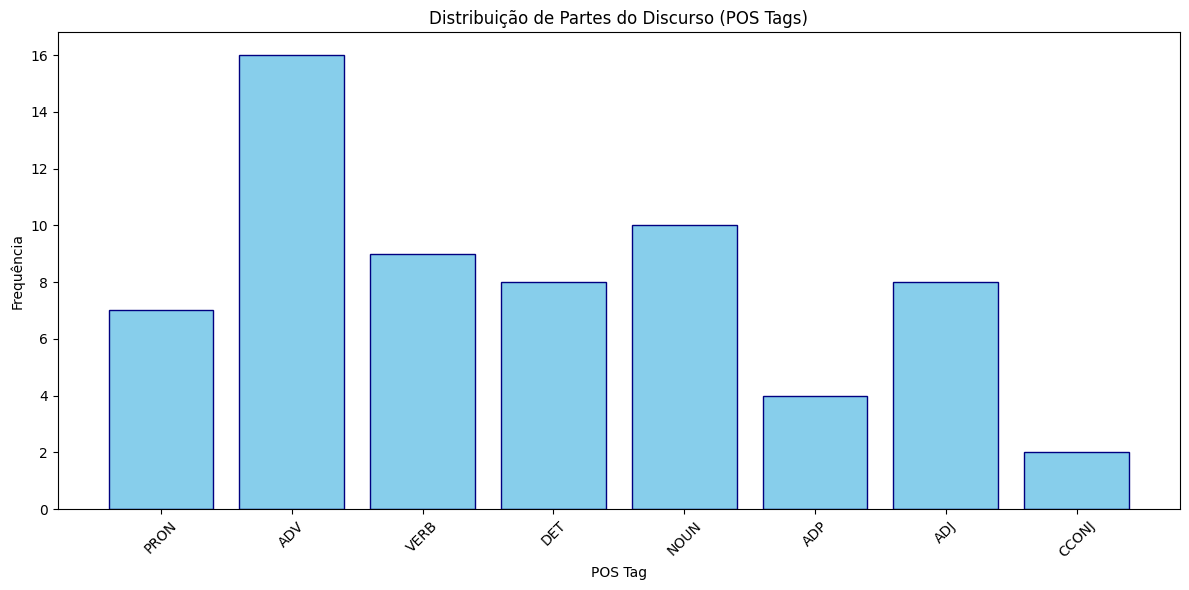

In [16]:
# 6. Visualizar distribuição
plt.figure(figsize=(12, 6))
pos_counts = Counter([token.pos_ for token in doc if token.is_alpha])
plt.bar(pos_counts.keys(), pos_counts.values(), color='skyblue', edgecolor='navy')
plt.xlabel('POS Tag')
plt.ylabel('Frequência')
plt.title('Distribuição de Partes do Discurso (POS Tags)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150)
plt.show()

# **NER**

In [17]:
# 1. NER com spaCy
doc = nlp(poema_exemplo)

print("ENTIDADES IDENTIFICADAS (spaCy NER):")
if len(doc.ents) > 0:
    for i, ent in enumerate(doc.ents, 1):
        print(f"  {i}. '{ent.text}' → Tipo: {ent.label_} (Confiança: {ent.start_char}-{ent.end_char})")
else:
    print("  Nenhuma entidade nomeada encontrada neste poema.")

# 2. Distribuição de tipos de entidades
from collections import Counter
ent_types = Counter([ent.label_ for ent in doc.ents])
print(f"\nDISTRIBUIÇÃO DE ENTIDADES:")
for ent_type, count in ent_types.most_common():
    print(f"  {ent_type:10} : {count:2d}")

# 3. Extrair entidades por tipo
print("\nENTIDADES POR TIPO:")
for ent_type in ent_types.keys():
    entidades = [ent.text for ent in doc.ents if ent.label_ == ent_type]
    print(f"  {ent_type}: {entidades}")

# 4. NER em múltiplos poemas
print("\nNER EM MÚLTIPLOS POEMAS:")
autores = ['Fernando Pessoa', 'Cecília Meireles', 'Carlos Drummond de Andrade', 'Vinicius de Moraes']

df_aut = df.copy()
df_aut = df_aut[df_aut['Author'].isin(autores)]

ner_por_author = {}
for author in autores:
    textos = df_aut[df_aut['Author'] == author]['Content'].values
    ents_author = []

    for texto in textos[:5]:  # Primeiros 5 poemas por autor
        doc = nlp(texto)
        for ent in doc.ents:
            ents_author.append(ent.text)

    ner_por_author[author] = ents_author
    print(f"\n{author}:")
    if ents_author:
        unique_ents = list(set(ents_author))[:10]
        print(f"  Entidades encontradas: {unique_ents}")
    else:
        print(f"  Sem entidades nomeadas.")


ENTIDADES IDENTIFICADAS (spaCy NER):
  1. 'Tão paradas e frias e mortas;
Eu não tinha este coração
Que nem' → Tipo: MISC (Confiança: 162-227)
  2. 'Tão' → Tipo: PER (Confiança: 271-274)

DISTRIBUIÇÃO DE ENTIDADES:
  MISC       :  1
  PER        :  1

ENTIDADES POR TIPO:
  MISC: ['Tão paradas e frias e mortas;\r\nEu não tinha este coração\r\nQue nem']
  PER: ['Tão']

NER EM MÚLTIPLOS POEMAS:

Fernando Pessoa:
  Entidades encontradas: ['De', 'Profundamente', 'Valeu', 'Que m’oprime', 'Vale', 'Portugal', 'Porque', 'Bojador Tem', 'O íntimo', 'Felizes']

Cecília Meireles:
  Entidades encontradas: ['Avisto', 'Minhas', 'Tão', 'Tão paradas e frias e mortas', 'sonho desapareça', 'Acabar', 'Pardais', 'Chorarei', 'Pensei', 'Marimbondos']

Carlos Drummond de Andrade:
  Entidades encontradas: ['Teresa', 'Lili', 'Maria', 'Ficaste', 'Teus', 'J. Pinto Fernandes', 'Raimundo', 'Estados Unidos', 'Deus', 'João']

Vinicius de Moraes:
  Entidades encontradas: ['lua', 'Ulcerai', 'Amo-te', 'Santa Janela da Con

# **Dependências Sintáticas**

In [18]:
# Pega o poema de exemplo e aplica algumas das principais etapas de nlp
# Tokenização, Tagging (POS), Parsing, NER (Named Entity Recognition)
doc = nlp(poema_exemplo.lower())

print("ANÁLISE DE DEPENDÊNCIAS SINTÁTICAS:")
print("Relações entre palavras (Token → Dependência → Head):\n")

# Mostrar primeiras 20 relações
count = 0
for token in doc:
    # Filtro: Ignora se for pontuação, espaço vazio/quebra de linha ou a própria raiz
    if not token.is_punct and not token.is_space and token.head != token:
        print(f"{token.text:12} →({token.dep_:8})→ {token.head.text}")
        count += 1

    # Limita aos 20 primeiros tokens
    if count == 20:
        break

# Árvore sintática - extração
print("\nÁRVORE SINTÁTICA (root):")

raizes_vistas = set()
contagem_raizes = 0

for token in doc:
    # Verifica se o token é a raiz, se não é pontuação/espaço e se já não foi impresso
    if token.head == token and not token.is_punct and not token.is_space:
        texto_raiz = token.text.strip()

        # Se o token não for raiz, adiciona como raiz e ao filtro raizes_vistas
        if texto_raiz not in raizes_vistas:
            raizes_vistas.add(texto_raiz)
            contagem_raizes += 1

            print(f"\n  Raiz: '{texto_raiz}'")

            # Filtra os filhos para remover a pontuação na árvore
            children = [child for child in token.children if not child.is_punct and not child.is_space]

            for child in children[:5]:
                print(f"    └─ {child.text} ({child.dep_})")

            # Limita a exibição às 3 primeiras raízes únicas
            if contagem_raizes == 3:
                break

# Extrair sintagmas nominais
print("\nSINTAGMAS NOMINAIS (Noun Chunks):")
vistos = set()
contados = 0

for chunk in doc.noun_chunks:
    texto_chunk = chunk.text.strip()

    # Verifica se o texto já apareceu
    if texto_chunk not in vistos:
        vistos.add(texto_chunk)
        contados += 1
        print(f"  {contados}. '{texto_chunk}' (head: {chunk.root.text})")

        # Para limitar aos 10 primeiros
        if contados == 10:
            break

# Análise de verbos e seus complementos
print("\nVERBOS E SEUS COMPLEMENTOS:")
for token in doc:
    if token.pos_ == "VERB":
        # Encontrar os complementos diretos
        complements = [child.text for child in token.children
                      if child.dep_ in ['dobj', 'attr']]
        if complements:
            print(f"  Verbo: '{token.text}' → Complementos: {complements}")

# Criar visualização
doc_sample = nlp(poema_exemplo[:300])  # Limitar tamanho para visualização
html = displacy.render(doc_sample, style='dep', page=True, manual=False)
try:
  with open('syntax_tree.html', 'w', encoding='utf-8') as f:
      f.write(html)
  print("\nVisualizacao salva em: syntax_tree.html")
except TypeError:
  print("")

# Métricas de complexidade sintática
print("\nCOMPLEXIDADE SINTÁTICA:")
num_tokens = len([token for token in doc if not token.is_punct])
num_deps = len(set([token.dep_ for token in doc]))
print(f"  Total de tokens (sem pontuação): {num_tokens}")
print(f"  Tipos diferentes de dependências: {num_deps}")
print(f"  Profundidade média: {sum([len(list(token.ancestors)) for token in doc]) / num_tokens:.2f}")

ANÁLISE DE DEPENDÊNCIAS SINTÁTICAS:
Relações entre palavras (Token → Dependência → Head):

eu           →(nsubj   )→ tinha
não          →(advmod  )→ tinha
este         →(det     )→ rosto
rosto        →(obj     )→ tinha
de           →(case    )→ hoje
hoje         →(advmod  )→ rosto
assim        →(advmod  )→ calmo
calmo        →(advcl   )→ tinha
assim        →(advmod  )→ calmo
triste       →(obl     )→ calmo
assim        →(advmod  )→ magro
magro        →(conj    )→ calmo
nem          →(cc      )→ olhos
estes        →(det     )→ olhos
olhos        →(conj    )→ calmo
tão          →(advmod  )→ vazios
vazios       →(amod    )→ olhos
nem          →(cc      )→ lábio
o            →(det     )→ lábio
lábio        →(conj    )→ tinha

ÁRVORE SINTÁTICA (root):

  Raiz: 'tinha'
    └─ eu (nsubj)
    └─ não (advmod)
    └─ rosto (obj)
    └─ calmo (advcl)
    └─ lábio (conj)

  Raiz: 'dei'
    └─ eu (nsubj)
    └─ não (advmod)
    └─ mudança (obj)
    └─ simples (amod)
    └─ ficou (acl:relcl)

SINTAG



COMPLEXIDADE SINTÁTICA:
  Total de tokens (sem pontuação): 75
  Tipos diferentes de dependências: 18
  Profundidade média: 2.69


### **Análise sobre a complexidade sintática**

---


**Total de Tokens = 75** │ Indica o tamanho efetivo do texto — neste caso, um trecho curto —, pois, normalmente, um poema apresenta alta concentração de significado em seus versos e menos redundância estrutural.

---

**Tipos diferentes de dependências = 18** │ Indica se há boa diversidade sintática, com o uso de diferentes relações (sujeito, objeto, modificadores, etc.) e a presença de estruturas variadas (orações, adjuntos, complementos). Ou seja, o texto não é monótono, há diversidade estrutural.

---
**Profundidade média = 2.35** │ Mede quantos níveis hierárquicos existem na árvore sintática (quantos 'degraus' há até a raiz). A pontuação média, nesse caso, apresenta profundidade baixa, as frases tendem a ser mais lineares, menos subordinadas a outras, revelando pouca recursividade (poucas orações encaixadas dentro de outras) e expondo um estilo mais direto, com menor complexidade sintática.


---



# **Pipeline**

In [21]:
# Código pipeline completo
largura = 70
print("\n" + "=" * largura)
print("PIPELINE NLTK".center(largura))
print("=" * largura)

# 1. Setando a função de Stemming
stemmer = RSLPStemmer()
stop_words = set(stopwords.words('portuguese'))

# 2. Pipeline tokens
def pipeline_tokens(texto):
    # Tokenização
    tokens_brutos = word_tokenize(texto, language='portuguese')

    # Limpeza
    tokens_limpos = [token.lower() for token in tokens_brutos
                     if token.lower() not in stop_words and token.isalpha()]

    # Stemming
    tokens_stem = [stemmer.stem(tk) for tk in tokens_limpos]

    return tokens_brutos, tokens_limpos, tokens_stem


# Pegando um poema de exemplo aleatório
poema_exemplo = df['Content'].sample(1, random_state=52).values[0]

# Começando tempo nltk
start = time.time()

# 3. Tokenização, limpeza e stemming aplicados
tokens, tokens_limpos, tokens_stem = pipeline_tokens(poema_exemplo)
tokens_ex = tokens_stem[:10]

# 4. Aplicando POS-TAG (NLTK não suporta pos_tag com português, por isso utilizamos eng)
pos_tags = nltk.pos_tag(tokens_limpos, lang='eng')

nltk_tempo = time.time() - start

print("\n  Resultados NLTK:")
print(f"\n  Tokens originais: {len(tokens)}")
print(f"  Tokens limpos: {len(tokens_limpos)}")
print(f"  POS Unicos: {len(set(tag for _, tag in pos_tags))}")
print(f"  Tempo de processamento: {nltk_tempo:.4f}s")

print("\nExemplos de tokens processados:")
for bruto, stem in zip(tokens_limpos[:10], tokens_stem[:10]):
    print(f"  {bruto:15} → {stem}")

# Spacy

print("\n" + "=" * largura)
print("PIPELINE spaCy".center(largura))
print("=" * largura)

# 1. Carregando configurações spacy
nlp = spacy.load('pt_core_news_sm', disable=["parser", "ner"])

# 2. Função pipeline
def pipeline_spacy(texto):
    doc = nlp(texto)
    # Tokenização e limpeza
    tokens = [token.text for token in doc if token.is_alpha]
    tokens_limpos = [token.text.lower() for token in doc if token.is_alpha and token.text.lower() not in stop_words]
    # Aplicando Lemmatização
    lemmas = [token.lemma_.lower() for token in doc if token.is_alpha and token.text.lower() not in stop_words]
    # Aplicando POS-TAG
    pos_tags = [(token.text, token.pos_) for token in doc if token.is_alpha]
    return doc, tokens, tokens_limpos, lemmas, pos_tags

# Começando tempo spacy
start = time.time()

doc, tokens_spacy, tokens_spacy_limpos, lemmas, pos_tags_spacy = pipeline_spacy(poema_exemplo)
spacy_time = time.time() - start

print(f"\n  Resultados spaCy:\n")
print(f"  Tokens: {len(tokens_spacy)}")
print(f"  Tokens limpos: {len(tokens_spacy_limpos)}")
print(f"  Lemmas únicos: {len(set(lemmas))}")
print(f"  POS tags únicos: {len(set(tag for _, tag in pos_tags_spacy))}")
print(f"  Tempo de processamento: {spacy_time:.4f}s")

print("\nExemplos de tokens processados:")
vistos = set()
for token in doc:
    if token.text.lower() in tokens_spacy_limpos and token.text.lower() not in vistos:
        print(f"  {token.text.lower():15} → lemma: {token.lemma_.lower():15} → {token.pos_}")
        vistos.add(token.text.lower())
        if len(vistos) == 10:
            break

# 3. COMPARAÇÃO

print("Comparação NLTK vs SPAcy")

print(f"\nspaCy é {nltk_tempo/spacy_time:.1f}x mais rápido" if spacy_time < nltk_tempo
      else f"\nNLTK é {spacy_time/nltk_tempo:.1f}x mais rápido")

print("\nVANTAGENS E DESVANTAGENS:")
print("""
  NLTK:
    ✓ Simples e de facil utilização
    ✓ Leve e sem dependências pesadas
    ✗ POS-TAG não tem suporte em português, apenas Inglês e Russo
    ✗ Stemming pode gerar raízes inválidas

  spaCy:
    ✓ Suporte nativo ao português
    ✓ Lemmatização linguisticamente correta
    ✓ Pipeline completo em uma única passagem
    ✗ Requer download de modelos de linguagem
""")

# 4. Aplicando em multiplos textos

print("\n" + "=" * largura)
print("APLICAÇÃO MÚLTIPLOS POEMAS".center(largura))
print("=" * largura)
print("\n")

resultados = []

for idx, row in df.head(10).iterrows():
    doc, tokens_s, tokens_s_limpos, lemmas_s, pos_s = pipeline_spacy(row['Content'])

    resultados.append({
        'titulo':        row['Title'],
        'tokens':        len(tokens_s),
        'tokens_limpos': len(tokens_s_limpos),
        'lemmas_unicos': len(set(lemmas_s)),
        'pos_unicos':    len(set(tag for _, tag in pos_s)),
    })

df_resultados = pd.DataFrame(resultados).set_index('titulo')
print(df_resultados.to_string(index=False))


                            PIPELINE NLTK                             

  Resultados NLTK:

  Tokens originais: 414
  Tokens limpos: 188
  POS Unicos: 7
  Tempo de processamento: 0.1680s

Exemplos de tokens processados:
  verdes          → verd
  têm             → têm
  usança          → usanç
  cor             → cor
  esperança       → esperanç
  obras           → obr
  rim             → rim
  uns             → um
  olhos           → olh
  verdes          → verd

                            PIPELINE spaCy                            

  Resultados spaCy:

  Tokens: 325
  Tokens limpos: 188
  Lemmas únicos: 103
  POS tags únicos: 12
  Tempo de processamento: 0.0304s

Exemplos de tokens processados:
  verdes          → lemma: verde           → NOUN
  têm             → lemma: ter             → VERB
  usança          → lemma: usança          → NOUN
  cor             → lemma: cor             → NOUN
  esperança       → lemma: esperança       → PROPN
  obras           → lemma: obra          

# **Análise Completa**


                 ANÁLISE COMPLETA: POEMAS PORTUGUESES                 

RESUMO POR AUTOR:
                                  Poemas  Tokens  Vocabulário  POS Tipos  Entidades  Tokens/Poema
Autor                                                                                            
Fernando Pessoa                     1914  201318        14253         17      10620           105
Sophia de Mello Breyner Andresen     440   40343         5801         16       2221            91
Eugénio de Andrade                    71    4068         1049         15         66            57
Vinicius de Moraes                    54    9189         2274         16        493           170


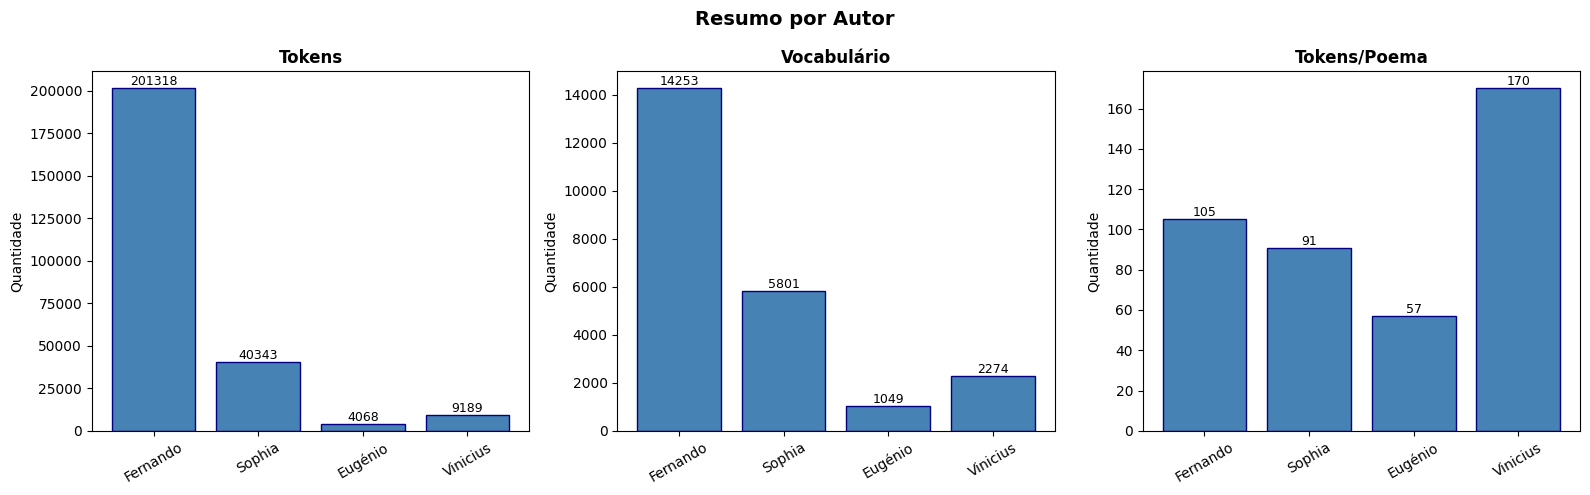


                     TERMOS MAIS COMUNS POR AUTOR                     

Fernando Pessoa:
  vida            : 1001
  eu              : 901
  alma            : 796
  deus            : 556
  pensar          : 532
  mundo           : 471
  dia             : 449
  sentir          : 417
  noite           : 407
  coração         : 386

Sophia de Mello Breyner Andresen:
  andresen        : 360
  mello           : 359
  breyner         : 359
  sophia          : 315
  mar             : 244
  dia             : 167
  poesia          : 126
  noite           : 124
  luz             : 112
  coisa           : 110

Eugénio de Andrade:
  palavra         :  23
  olho            :  22
  luz             :  19
  água            :  17
  terra           :  17
  mão             :  17
  amor            :  16
  boca            :  16
  rio             :  15
  lábio           :  15

Vinicius de Moraes:
  mulher          :  46
  piedade         :  42
  amor            :  40
  hoje            :  40
  sábado        

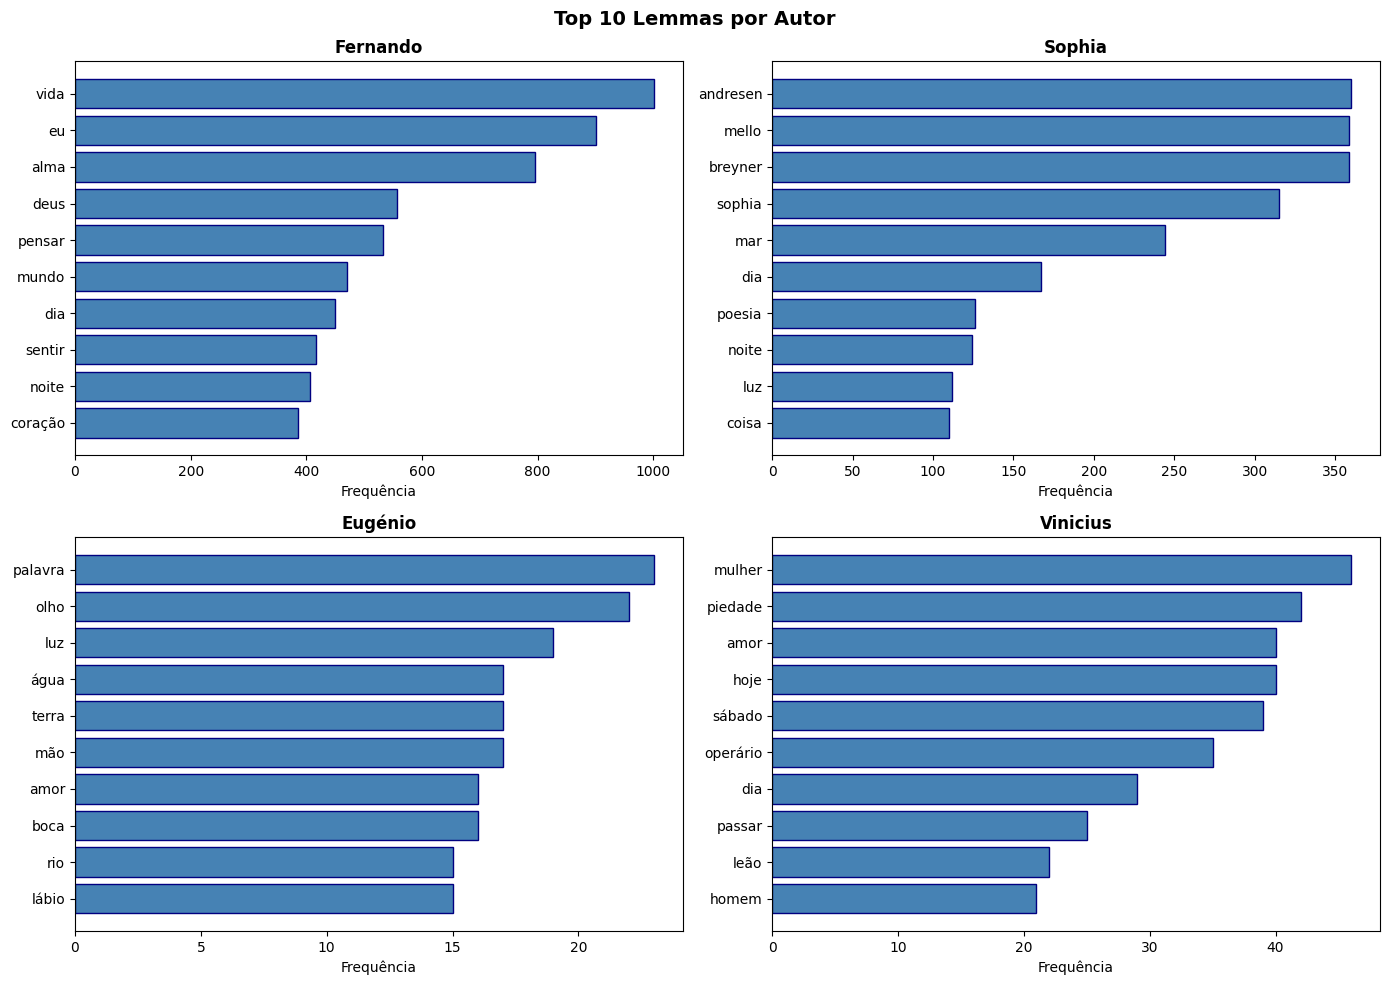


                  DISTRIBUIÇÃO DE POS TAGS POR AUTOR                  

Fernando Pessoa:
  NOUN       : 41232
  VERB       : 25801
  ADP        : 24479
  DET        : 22831
  PRON       : 19006
  ADV        : 14715
  ADJ        : 11249
  CCONJ      : 9809
  SCONJ      : 8753
  PROPN      : 7795
  AUX        : 7253
  NUM        :  659
  INTJ       :  393
  PUNCT      :   15
  X          :   14
  SYM        :    3

Sophia de Mello Breyner Andresen:
  NOUN       : 9443
  ADP        : 6000
  DET        : 4951
  VERB       : 4311
  PROPN      : 3480
  ADJ        : 2353
  PRON       : 2219
  CCONJ      : 1913
  ADV        : 1795
  SCONJ      :  938
  AUX        :  850
  NUM        :  157
  PUNCT      :   21
  X          :    9
  INTJ       :    3

Eugénio de Andrade:
  NOUN       : 1014
  DET        :  533
  ADP        :  520
  VERB       :  514
  ADV        :  268
  ADJ        :  250
  PRON       :  248
  CCONJ      :  164
  SCONJ      :  157
  AUX        :  127
  PROPN      :   82
  NUM  

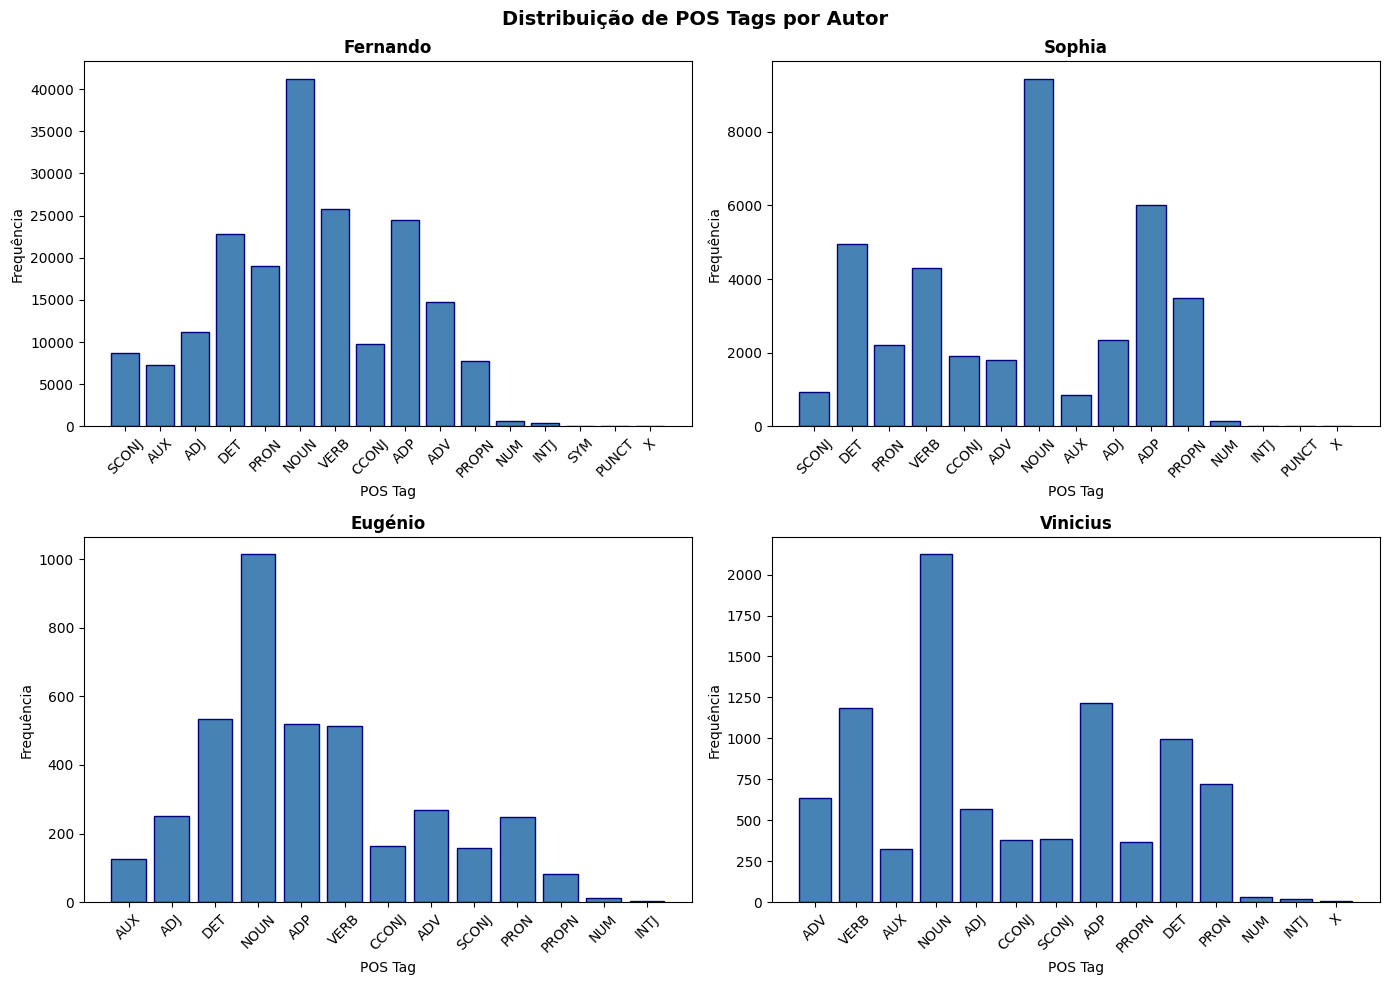


                        COMPLEXIDADE SINTÁTICA                        

Fernando Pessoa:
  Profundidade média: 1.90

Sophia de Mello Breyner Andresen:
  Profundidade média: 2.25

Eugénio de Andrade:
  Profundidade média: 2.27

Vinicius de Moraes:
  Profundidade média: 1.91


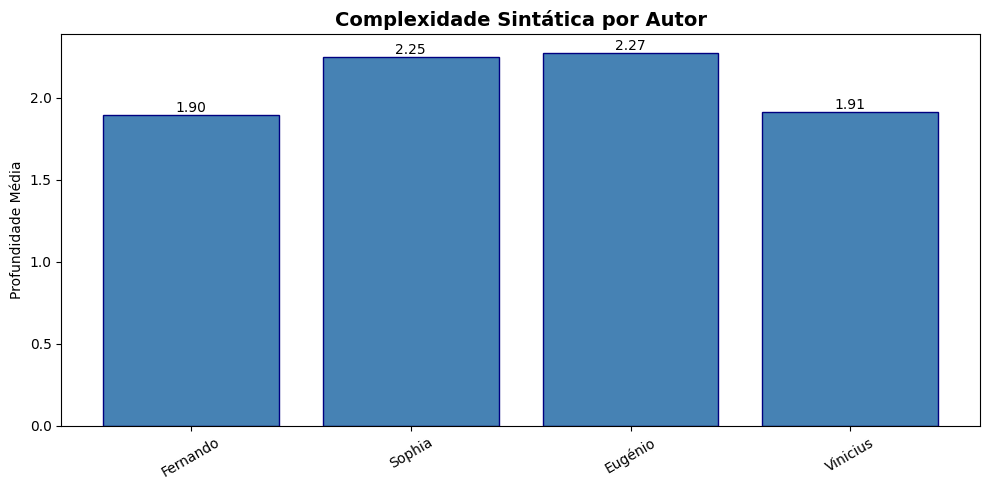


                            SUMÁRIO FINAL                             

Total de poemas analisados: 2479
Autores analisados: 4

Distribuição:
  Fernando Pessoa: 1914 poemas
  Sophia de Mello Breyner Andresen: 440 poemas
  Eugénio de Andrade: 71 poemas
  Vinicius de Moraes: 54 poemas

Ferramentas utilizadas:
  ✓ NLTK: Tokenização, Stemming, POS-Tagging
  ✓ spaCy: Pipeline completo, NER, análise sintática

Análises realizadas:
  ✓ Tokenização e análise estrutural
  ✓ Normalização e stemming
  ✓ POS-Tagging e análise sintática
  ✓ NER (Reconhecimento de Entidades)
  ✓ Dependências sintáticas
  ✓ Análise comparativa NLTK vs spaCy
  ✓ Análise completa por autor
  ✓ Múltiplos gráficos de análise



In [22]:

# Análise completa - Poemas Portugueses
aut = ['Fernando Pessoa', 'Sophia de Mello Breyner Andresen', 'Eugénio de Andrade', 'Vinicius de Moraes']
df_aut = df[df['Author'].isin(aut)].dropna(subset=['Content'])

# Função para retornar apenas texto em português
def is_portuguese(text):
    try:
        return detect(text) == 'pt'
    except:
        return False

df_aut = df_aut[df_aut['Content'].apply(is_portuguese)]


# Carregando spaCy
nlp_full = spacy.load('pt_core_news_sm')

largura = 70
print("\n" + "=" * largura)
print("ANÁLISE COMPLETA: POEMAS PORTUGUESES".center(largura))
print("=" * largura)

# 1. Resumo por autor
analise_autores = []
for autor in aut:
    textos = df_aut[df_aut['Author'] == autor]['Content'].values

    todos_tokens, todos_lemmas, todos_pos, todas_ents = [], [], [], []

    for texto in textos:
        doc = nlp_full(texto)
        todos_tokens.extend([t.text for t in doc if not t.is_punct])
        todos_lemmas.extend([t.lemma_ for t in doc if t.is_alpha])
        todos_pos.extend([t.pos_ for t in doc])
        todas_ents.extend([ent.label_ for ent in doc.ents])

    analise_autores.append({
        'Autor':        autor,
        'Poemas':       len(textos),
        'Tokens':       len(todos_tokens),
        'Vocabulário':  len(set(todos_lemmas)),
        'POS Tipos':    len(set(todos_pos)),
        'Entidades':    len(todas_ents),
        'Tokens/Poema': len(todos_tokens) // len(textos) if len(textos) > 0 else 0
    })

df_analise = pd.DataFrame(analise_autores).set_index('Autor')
print("\nRESUMO POR AUTOR:")
print(df_analise.to_string())

autores_curtos = [a.split()[0] for a in aut]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = ['Tokens', 'Vocabulário', 'Tokens/Poema']

for i, metrica in enumerate(metricas):
    axes[i].bar(autores_curtos, df_analise[metrica], color='steelblue', edgecolor='navy')
    axes[i].set_title(metrica, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Quantidade')
    axes[i].tick_params(axis='x', rotation=30)
    for j, val in enumerate(df_analise[metrica]):
        axes[i].text(j, val, str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Resumo por Autor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resumo_autores.png', dpi=150)
plt.show()

# 2. Termos mais comuns por autor
print("\n" + "="*largura)
print("TERMOS MAIS COMUNS POR AUTOR".center(largura))
print("="*largura)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, autor in enumerate(aut):
    textos = df_aut[df_aut['Author'] == autor]['Content'].values
    todos_lemmas = []

    for texto in textos:
        doc = nlp_full(texto)
        todos_lemmas.extend([t.lemma_.lower() for t in doc
                             if t.is_alpha and not t.is_stop and t.text.lower() not in stop_words])

    freq = Counter(todos_lemmas)
    print(f"\n{autor}:")
    for lemma, count in freq.most_common(10):
        print(f"  {lemma:15} : {count:3d}")

    top_lemmas = freq.most_common(10)
    palavras, contagens = zip(*top_lemmas) if top_lemmas else ([], [])

    axes[idx].barh(list(palavras)[::-1], list(contagens)[::-1], color='steelblue', edgecolor='navy')
    axes[idx].set_title(autor.split()[0], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Frequência')

plt.suptitle('Top 10 Lemmas por Autor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('termos_comuns.png', dpi=150)
plt.show()

# 3. Distribuição POS tags por autor
print("\n" + "="*largura)
print("DISTRIBUIÇÃO DE POS TAGS POR AUTOR".center(largura))
print("="*largura)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, autor in enumerate(aut):
    textos = df_aut[df_aut['Author'] == autor]['Content'].values
    todos_pos = []

    for texto in textos:
        doc = nlp_full(texto)
        todos_pos.extend([t.pos_ for t in doc if t.is_alpha])

    pos_dist = Counter(todos_pos)
    print(f"\n{autor}:")
    for pos, count in pos_dist.most_common():
        print(f"  {pos:10} : {count:4d}")

    axes[idx].bar(pos_dist.keys(), pos_dist.values(), color='steelblue', edgecolor='navy')
    axes[idx].set_title(autor.split()[0], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('POS Tag')
    axes[idx].set_ylabel('Frequência')
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Distribuição de POS Tags por Autor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pos_tags.png', dpi=150)
plt.show()

# 4. Complexidade sintática
print("\n" + "="*largura)
print("COMPLEXIDADE SINTÁTICA".center(largura))
print("="*largura)

complexidade = []
for autor in aut:
    textos = df_aut[df_aut['Author'] == autor]['Content'].values

    prof_media = 0
    num_textos = 0

    for texto in textos:
        doc = nlp_full(texto)
        if len(doc) > 0:
            prof = sum([len(list(token.ancestors)) for token in doc]) / len(doc)
            prof_media += prof
            num_textos += 1

    if num_textos > 0:
        prof_media /= num_textos

    complexidade.append({'Autor': autor, 'Profundidade Media': prof_media})
    print(f"\n{autor}:")
    print(f"  Profundidade média: {prof_media:.2f}")

df_complexidade = pd.DataFrame(complexidade).set_index('Autor')
plt.figure(figsize=(10, 5))
plt.bar(autores_curtos, df_complexidade['Profundidade Media'], color='steelblue', edgecolor='navy')
plt.title('Complexidade Sintática por Autor', fontsize=14, fontweight='bold')
plt.ylabel('Profundidade Média')
plt.xticks(rotation=30)
for i, val in enumerate(df_complexidade['Profundidade Media']):
    plt.text(i, val, f"{val:.2f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('complexidade_sintatica.png', dpi=150)
plt.show()

# 5. Sumário final
print("\n" + "="*largura)
print("SUMÁRIO FINAL".center(largura))
print("="*largura)

print(f"\nTotal de poemas analisados: {len(df_aut)}")
print(f"Autores analisados: {len(aut)}\n")
print("Distribuição:")
for autor in aut:
    print(f"  {autor}: {len(df_aut[df_aut['Author'] == autor])} poemas")

print("""
Ferramentas utilizadas:
  ✓ NLTK: Tokenização, Stemming, POS-Tagging
  ✓ spaCy: Pipeline completo, NER, análise sintática

Análises realizadas:
  ✓ Tokenização e análise estrutural
  ✓ Normalização e stemming
  ✓ POS-Tagging e análise sintática
  ✓ NER (Reconhecimento de Entidades)
  ✓ Dependências sintáticas
  ✓ Análise comparativa NLTK vs spaCy
  ✓ Análise completa por autor
  ✓ Múltiplos gráficos de análise
""")